# Analisis del tiempo de juego a jugadores de la plataforma steam

## Imports iniciales

In [6]:
import re

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from kagglehub import KaggleDatasetAdapter
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor


In [7]:
df_playtime = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/reviews.csv",
)

In [8]:
df_apps = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/applications.csv",
)

/home/esnore/University/mineria-steam-games/.venv/lib/python3.14/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [9]:
df_application_genres = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/application_genres.csv",
)

In [10]:
df_application_platforms = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/application_platforms.csv",
)

In [11]:
df_genres = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abhishekgupta56447/steam-games-dataset-2025",
    "steam_dataset_2025_csv/genres.csv",
)

In [12]:
df_apps.drop(
    columns=[
        "header_image",
        "background",
        "mat_supports_windows",
        "mat_supports_mac",
        "mat_supports_linux",
        "mat_initial_price",
        "mat_final_price",
        "mat_discount_percent",
        "mat_currency",
        "mat_achievement_count",
        "mat_pc_os_min",
        "mat_pc_processor_min",
        "mat_pc_memory_min",
        "mat_pc_graphics_min",
        "mat_pc_os_rec",
        "mat_pc_processor_rec",
        "mat_pc_memory_rec",
        "mat_pc_graphics_rec",
    ],
)
df_apps.to_csv("./data-cleaned/applications.csv")
!python clean.py

## Primeros Insights y comportamiento del set de datos

### Exploracion simple de los conjuntos de datos con medidas de tendencia central

In [13]:
print(f"Reviews cargadas: {len(df_playtime):,}")
print(f"Nulos: {df_playtime['author_playtime_forever'].isna().sum():,}")

df_playtime = df_playtime.dropna()

# Convertir minutos a horas
df_playtime["playtime_hours"] = df_playtime["author_playtime_forever"] / 60

# Calcular promedio por juego
playtime_avg = (
    df_playtime.groupby("appid")["playtime_hours"]
    .agg(playtime_mean="mean", playtime_median="median", n_reviews="count")
    .reset_index()
)

print(f"\nJuegos con datos de playtime: {len(playtime_avg):,}")
print(playtime_avg.describe())

Reviews cargadas: 1,048,148
Nulos: 3

Juegos con datos de playtime: 86,188
              appid  playtime_mean  playtime_median     n_reviews
count  8.618800e+04   86188.000000     86188.000000  86188.000000
mean   1.677076e+06      19.443003        12.362427     10.077122
std    9.840676e+05     155.751041       131.641531     19.577455
min    4.000000e+02       0.016667         0.016667      1.000000
25%    8.336350e+05       1.077778         0.791667      1.000000
50%    1.565205e+06       3.300000         2.350000      3.000000
75%    2.434515e+06       9.904960         7.066667      9.000000
max    3.959570e+06   21297.116667     21297.116667    100.000000


### Distribucion de tiempo de juego entre los juegos de steam

Juegos filtrados: 32,014


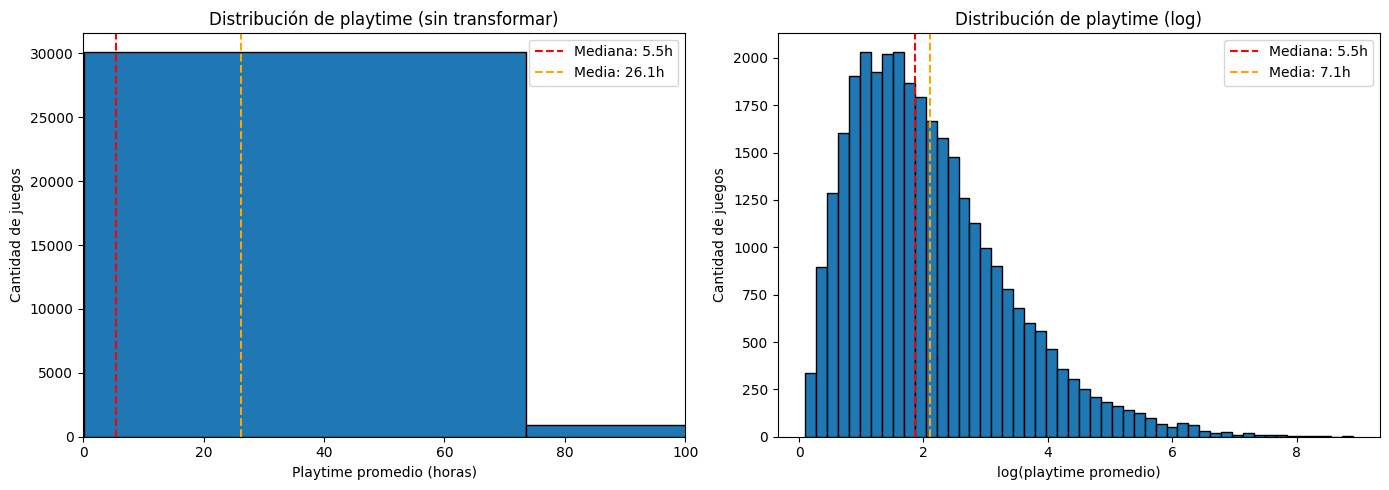

count    32014.000000
mean        26.133977
std        127.074742
min          0.103333
25%          2.148148
50%          5.478977
75%         15.207773
max       7340.052941
Name: playtime_mean, dtype: float64


In [14]:
# Filtrar juegos con al menos 5 reviews (promedio más confiable)
# Filtrar juegos con >= 5 reviews Y playtime > 0
MIN_REVIEWS = 5
playtime_filtrado = playtime_avg[
    (playtime_avg["n_reviews"] >= MIN_REVIEWS)
    & (playtime_avg["playtime_mean"] > 0)
].copy()
print(f"Juegos filtrados: {len(playtime_filtrado):,}")

# Calcular estadísticas
media = playtime_filtrado["playtime_mean"].mean()
mediana = playtime_filtrado["playtime_mean"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin transformar
axes[0].hist(playtime_filtrado["playtime_mean"], bins=100, edgecolor="black")
axes[0].axvline(
    mediana,
    color="red",
    linestyle="--",
    label=f"Mediana: {mediana:.1f}h",
)
axes[0].axvline(
    media,
    color="orange",
    linestyle="--",
    label=f"Media: {media:.1f}h",
)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Playtime promedio (horas)")
axes[0].set_ylabel("Cantidad de juegos")
axes[0].set_title("Distribución de playtime (sin transformar)")
axes[0].legend()

# Con log
log_media = np.log1p(playtime_filtrado["playtime_mean"]).mean()
log_mediana = np.log1p(playtime_filtrado["playtime_mean"]).median()

# Invertir para mostrar en horas reales
media_real = np.expm1(log_media)
mediana_real = np.expm1(log_mediana)

axes[1].hist(
    np.log1p(playtime_filtrado["playtime_mean"]),
    bins=50,
    edgecolor="black",
)
axes[1].axvline(
    log_mediana,
    color="red",
    linestyle="--",
    label=f"Mediana: {mediana_real:.1f}h",
)
axes[1].axvline(
    log_media,
    color="orange",
    linestyle="--",
    label=f"Media: {media_real:.1f}h",
)
axes[1].set_xlabel("log(playtime promedio)")
axes[1].set_ylabel("Cantidad de juegos")
axes[1].set_title("Distribución de playtime (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(playtime_filtrado["playtime_mean"].describe())

## Eleccion de features para la prediccion del tiempo de juego

In [15]:
# Cargar datos limpios
df_apps = pd.read_csv("./data-cleaned/applications.csv", low_memory=False)

In [16]:
# Merge playtime con applications
df_model = playtime_filtrado.merge(df_apps, on="appid", how="inner")
print(f"Juegos tras merge: {len(df_model):,}")

# --- Features originales ---
def count_langs(x):
    if pd.isna(x):
        return 0
    clean = re.sub(r"<[^>]+>", "", str(x))
    clean = re.sub(r"\*", "", clean)
    return len([x for x in clean.split(",") if x.strip()])


df_model["n_languages"] = df_model["supported_languages"].apply(count_langs)
df_model["price_usd"] = df_model["mat_final_price"] / 100
df_model["release_date"] = pd.to_datetime(
    df_model["release_date"],
    errors="coerce",
)
df_model["release_year"] = df_model["release_date"].dt.year

n_genres = df_application_genres.groupby("appid").size().rename("n_genres")
n_platforms = (
    df_application_platforms.groupby("appid").size().rename("n_platforms")
)
df_model = df_model.merge(n_genres, on="appid", how="left")
df_model = df_model.merge(n_platforms, on="appid", how="left")

# Target
df_model["log_playtime"] = np.log1p(df_model["playtime_mean"])

# Filtrar outliers de precio
MAX_PRICE_USD = 60
df_model = df_model[df_model["price_usd"] <= MAX_PRICE_USD].copy()

# --- Ronda 1: Features de applications ---
df_model["mat_discount_percent"] = df_model["mat_discount_percent"].fillna(0)
df_model["has_discount"] = (df_model["mat_discount_percent"] > 0).astype(int)
df_model["log_recs"] = np.log1p(df_model["recommendations_total"].fillna(0))

# --- Ronda 2: Features de reviews ---
review_stats = pd.read_csv(
    "data/reviews.csv",
    usecols=[
        "appid",
        "voted_up",
        "steam_purchase",
        "author_num_games_owned",
        "votes_up",
    ],
)

review_agg = (
    review_stats.groupby("appid")
    .agg(
        pct_positive=("voted_up", "mean"),
        pct_steam_purchase=("steam_purchase", "mean"),
        avg_games_owned=("author_num_games_owned", "mean"),
        avg_votes_up=("votes_up", "mean"),
    )
    .reset_index()
)

df_model = df_model.merge(review_agg, on="appid", how="left")

# --- Ronda 3: Géneros one-hot (top 10) ---
app_gen = df_application_genres.merge(
    df_genres,
    left_on="genre_id",
    right_on="id",
)
app_gen = app_gen.rename(columns={"name": "genre_name"})

top10 = app_gen["genre_name"].value_counts().head(10).index.tolist()
print("Top 10 géneros:", top10)

for genre in top10:
    col_name = f"genre_{genre.lower().replace(' ', '_')}"
    apps_with_genre = app_gen[app_gen["genre_name"] == genre]["appid"].unique()
    df_model[col_name] = df_model["appid"].isin(apps_with_genre).astype(int)

# --- Features finales ---
genre_cols = [c for c in df_model.columns if c.startswith("genre_")]

features_v2 = [
    # Originales
    "price_usd",
    "mat_achievement_count",
    "n_genres",
    "n_platforms",
    "n_languages",
    "release_year",
    # Nuevas de applications
    "mat_discount_percent",
    "has_discount",
    "log_recs",
    # Nuevas de reviews
    "pct_positive",
    "pct_steam_purchase",
    "avg_games_owned",
    "avg_votes_up",
] + genre_cols

print(f"\nTotal features: {len(features_v2)}")

modelo_df = df_model[[*features_v2, "log_playtime"]].dropna()
print(f"Filas para modelar: {len(modelo_df):,}")
print(modelo_df.describe())

Juegos tras merge: 32,014
Top 10 géneros: ['Indie', 'Action', 'Casual', 'Adventure', 'Simulation', 'RPG', 'Strategy', 'Free To Play', 'Early Access', 'Sports']

Total features: 23
Filas para modelar: 18,916
          price_usd  mat_achievement_count      n_genres   n_platforms  \
count  18916.000000           18916.000000  18916.000000  18916.000000   
mean      10.505316              36.070734      2.852876      1.438412   
std       10.296727             154.363972      1.296400      0.733520   
min        0.490000               0.000000      1.000000      1.000000   
25%        2.990000              11.000000      2.000000      1.000000   
50%        6.990000              21.000000      3.000000      1.000000   
75%       14.990000              38.000000      4.000000      2.000000   
max       60.000000            5000.000000     10.000000      3.000000   

        n_languages  release_year  mat_discount_percent  has_discount  \
count  18916.000000  18916.000000          18916.0000

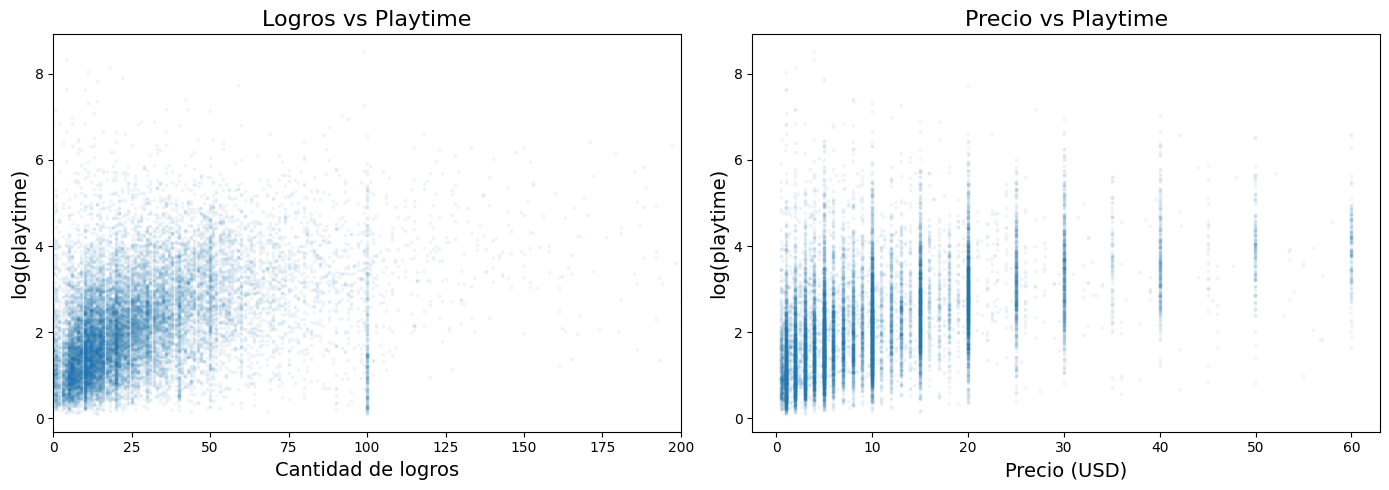

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# achievements vs playtime
axes[0].scatter(
    modelo_df["mat_achievement_count"],
    modelo_df["log_playtime"],
    alpha=0.05,
    s=3,
)
axes[0].set_xlim(0, 200)
axes[0].set_xlabel("Cantidad de logros", fontsize=14)
axes[0].set_ylabel("log(playtime)", fontsize=14)
axes[0].set_title("Logros vs Playtime", fontsize=16)

# price vs playtime
axes[1].scatter(
    modelo_df["price_usd"],
    modelo_df["log_playtime"],
    alpha=0.05,
    s=3,
)
axes[1].set_xlabel("Precio (USD)", fontsize=14)
axes[1].set_ylabel("log(playtime)", fontsize=14)
axes[1].set_title("Precio vs Playtime", fontsize=16)

plt.tight_layout()
plt.show()

Se puede notar que juegos con cerca de 25 logros, tienen cierta tendencia a tener tiempo de juego cercano a 5-10 horas de juego. También se puede notar una nube de puntos cercana en los valores bajos. Como singularidad, los juegos con 100 logros también tienen una cantidad notable de gente que los juega. Se puede apreciar una tendencia entre la cantidad de logos con el tiempo de juego.

Por otro lado, también se puede ver una tendencia del precio con el tiempo de juego. A medida que aumenta el precio, la densidad de puntos se concentra más en valores altos de tiempo de juego.

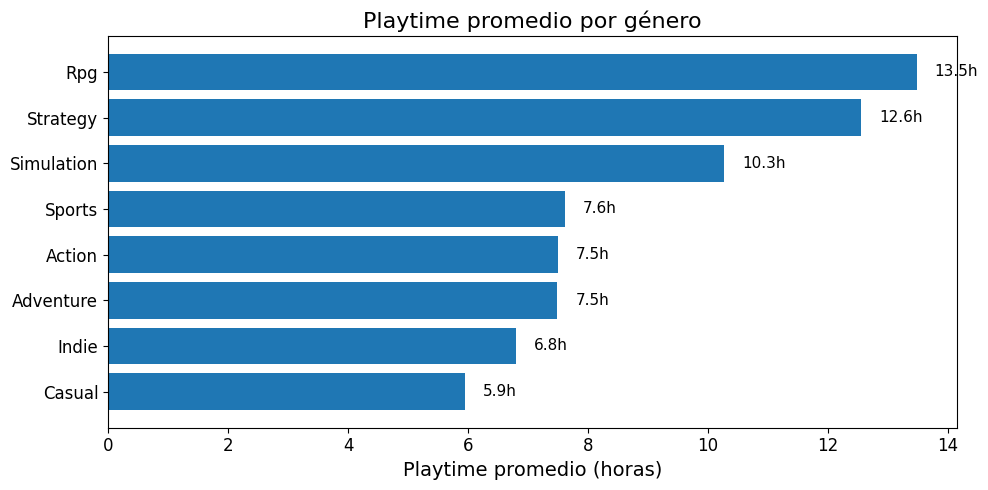

In [18]:
# Gráfico 2 — Playtime promedio por género

generos = [
    "genre_indie",
    "genre_action",
    "genre_casual",
    "genre_adventure",
    "genre_simulation",
    "genre_rpg",
    "genre_strategy",
    "genre_sports",
]

medias = []
for g in generos:
    media = modelo_df[modelo_df[g] == 1]["log_playtime"].mean()
    nombre = g.replace("genre_", "").replace("_", " ").title()
    medias.append(
        {
            "Género": nombre,
            "Playtime promedio (log)": media,
            "Playtime promedio (horas)": np.expm1(media),
        },
    )

df_generos = pd.DataFrame(medias).sort_values(
    "Playtime promedio (horas)",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_generos["Género"], df_generos["Playtime promedio (horas)"])
ax.set_xlabel("Playtime promedio (horas)", fontsize=14)
ax.set_title("Playtime promedio por género", fontsize=16)
ax.tick_params(labelsize=12)

# Agregar valores en las barras
for bar, val in zip(
    bars,
    df_generos["Playtime promedio (horas)"],
    strict=False,
):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}h",
        va="center",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

Aqui se puede apreciar que los géneros de RPG, Estrategia y Simulación son géneros que usualmente poseen un mayor promedio de tiempo de juego.

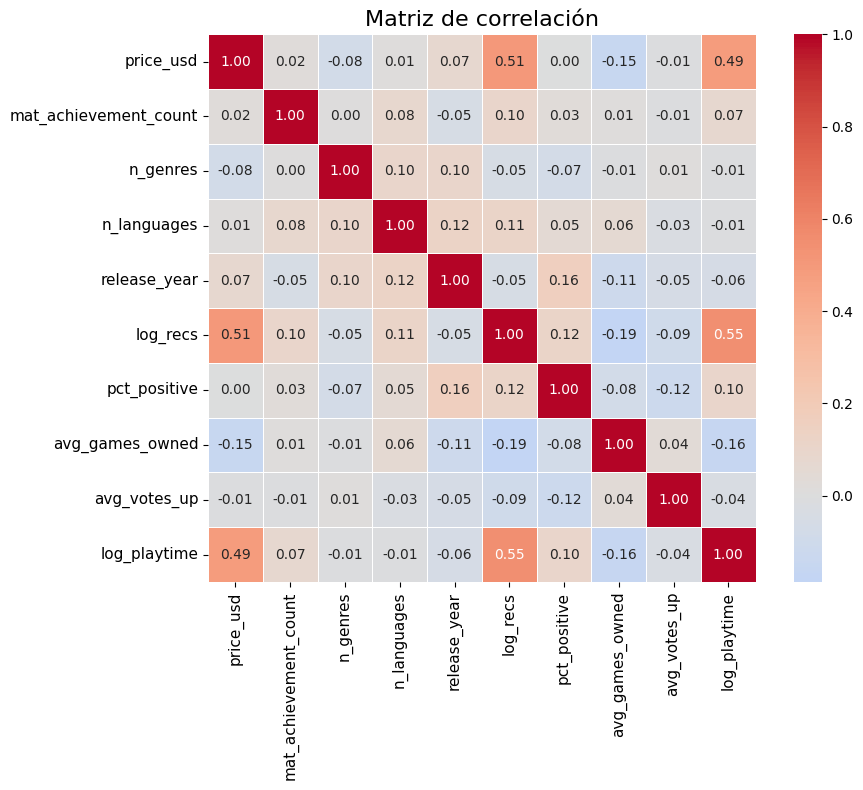

In [19]:
# Gráfico 3 — Correlación entre features numéricas
cols_corr = [
    "price_usd",
    "mat_achievement_count",
    "n_genres",
    "n_languages",
    "release_year",
    "log_recs",
    "pct_positive",
    "avg_games_owned",
    "avg_votes_up",
    "log_playtime",
]

corr = modelo_df[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de correlación", fontsize=16)
plt.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

Las variables que más nos llamaron la atención son la cantidad de recomendaciones y el precio del juego, pues eran las que estaban más relacionadas con el tiempo de juego.

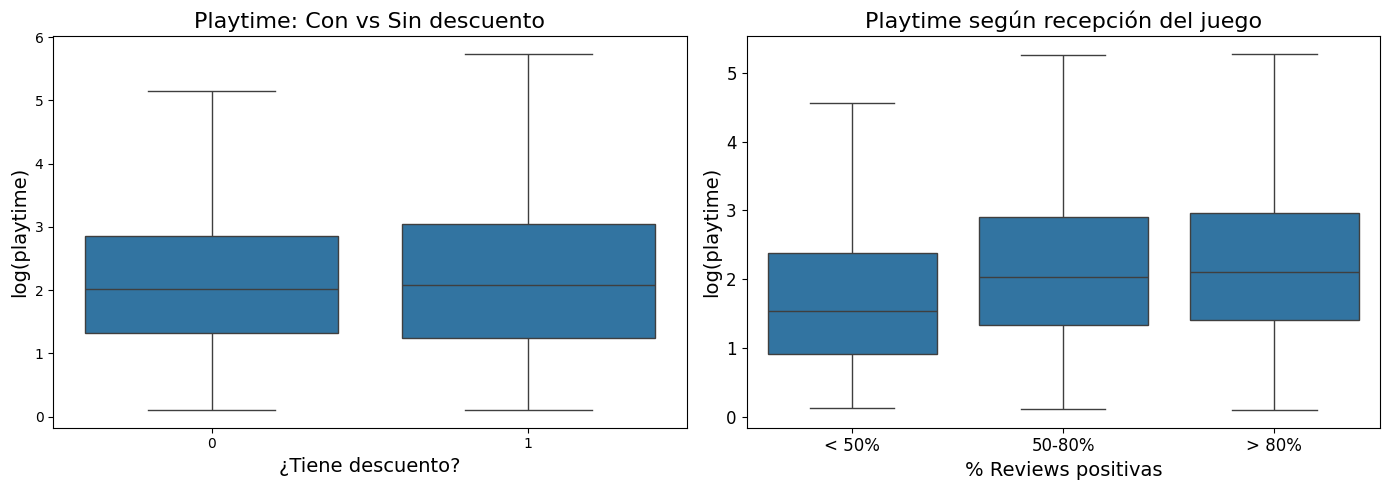

In [20]:
# Gráfico 4 — Boxplot de playtime: con descuento vs sin descuento

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Descuento
sns.boxplot(
    data=modelo_df,
    x="has_discount",
    y="log_playtime",
    ax=axes[0],
    showfliers=False,
)
axes[0].set_xlabel("¿Tiene descuento?", fontsize=14)
axes[0].set_ylabel("log(playtime)", fontsize=14)
axes[0].set_title("Playtime: Con vs Sin descuento", fontsize=16)

# % reviews positivas (dividido en 3 grupos)
modelo_df["review_tier"] = pd.cut(
    modelo_df["pct_positive"],
    bins=[0, 0.5, 0.8, 1.0],
    labels=["< 50%", "50-80%", "> 80%"],
)
sns.boxplot(
    data=modelo_df,
    x="review_tier",
    y="log_playtime",
    ax=axes[1],
    showfliers=False,
)
axes[1].set_xlabel("% Reviews positivas", fontsize=14)
axes[1].set_ylabel("log(playtime)", fontsize=14)
axes[1].set_title("Playtime según recepción del juego", fontsize=16)
axes[1].tick_params(labelsize=12)

plt.tight_layout()
plt.show()

El que un juego tenga descuento o no, no influye de manera importante en la cantidad de tiempo de juego de cada usuario. Solo hace más disperso los valores cuando existe un descuento.

Las reviews positivas si son relativamente influyentes, pues la mediana se desplaza al tener una mayor cantidad de reviews positivas.

In [21]:
features_v2 = [f for f in features_v2 if f != "pct_steam_purchase"]

Correlación de cada feature con log(playtime):
log_recs                 0.549979
price_usd                0.488373
genre_rpg                0.210881
genre_strategy           0.181094
genre_simulation         0.104421
pct_positive             0.100694
n_platforms              0.078354
mat_achievement_count    0.074696
genre_early_access       0.039691
has_discount             0.020178
mat_discount_percent     0.005973
genre_free_to_play       0.003072
genre_sports            -0.007678
n_genres                -0.008244
n_languages             -0.011288
avg_votes_up            -0.036925
genre_adventure         -0.043659
genre_action            -0.043744
release_year            -0.058326
avg_games_owned         -0.157367
genre_casual            -0.181468
genre_indie             -0.211296
Name: log_playtime, dtype: float64


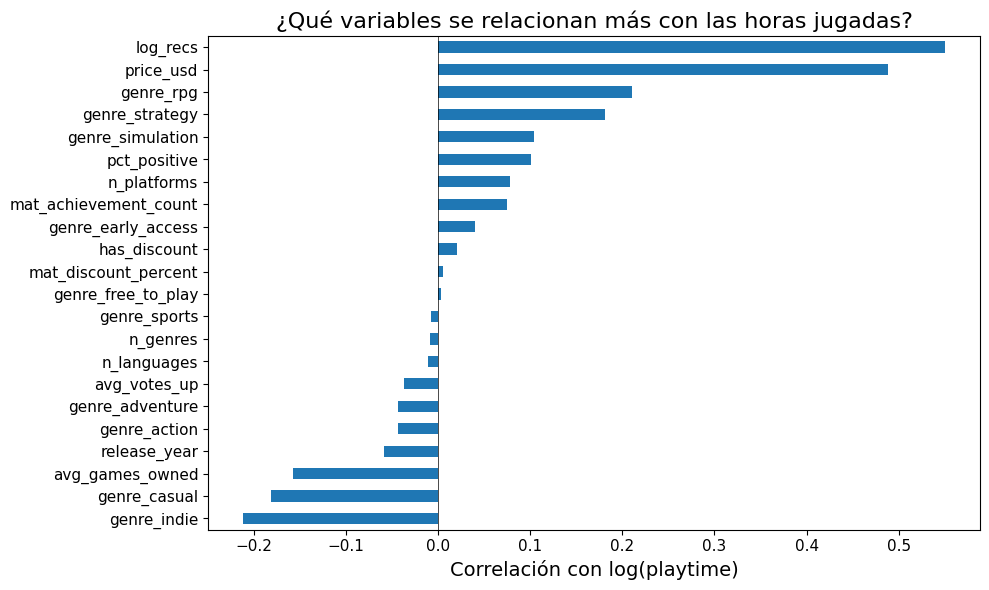

In [22]:
# === Correlación de cada feature con el target ===
correlaciones = (
    modelo_df[[*features_v2, "log_playtime"]]
    .corr()["log_playtime"]
    .drop("log_playtime")
    .sort_values(ascending=False)
)

print("Correlación de cada feature con log(playtime):")
print(correlaciones)

plt.figure(figsize=(10, 6))
correlaciones.sort_values().plot.barh()
plt.xlabel("Correlación con log(playtime)", fontsize=14)
plt.title(
    "¿Qué variables se relacionan más con las horas jugadas?",
    fontsize=16,
)
plt.axvline(0, color="black", linewidth=0.5)
plt.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

Con estos resultados obtenidos, se puede plantear la hipótesis de que los atributos: cantidad de recomendaciones, precio del juego, el género RPG y el género de Estrategia son más probables a influir en la cantidad de tiempo de juego en los usuarios de Steam. Esto se puede confirmar en nuestra experiencia. Es evidente que en juegos populares va a existir una mayor cantidad de tiempo jugado. Para los juegos caros, se puede suponer que para poder retribuir el coste monetario del juego, se invierte en tiempo de juego, para que esas horas de juego "valgan la pena". Y los juegos RPG y de Estrategia, son juegos conocidos por ser de larga duración para ser completados, lo que se traduce en un mayor tiempo de juego involucrado.

Con el último gráfico también se pueden encontrar otras hipótesis. Los juegos Indie son experiencias cortas, por lo que no requiere mucho tiempo de juego para ser completados. Existen casos especiales donde existen juegos Indie que son populares, pero por lo general no sucede. Lo mismo sucede para los juegos Casuales, dado el nombre que tienen. Otro punto es la cantidad promedio de juegos que posee cada usuario, ya que si posee una gran cantidad de juegos, tienen que repartir su tiempo entre ellos, lo que significa menos tiempo invertido en cada uno de los juegos.

## Entrenamiento de 4 modelos distintos

### Separacion de train y test

In [ ]:
features = features_v2
X = modelo_df[features]
y = modelo_df["log_playtime"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Index(['price_usd', 'mat_achievement_count', 'n_genres', 'n_platforms',
       'n_languages', 'release_year', 'mat_discount_percent', 'has_discount',
       'log_recs', 'pct_positive', 'pct_steam_purchase', 'avg_games_owned',
       'avg_votes_up', 'genre_indie', 'genre_action', 'genre_casual',
       'genre_adventure', 'genre_simulation', 'genre_rpg', 'genre_strategy',
       'genre_free_to_play', 'genre_early_access', 'genre_sports',
       'log_playtime', 'review_tier'],
      dtype='str')
X_train: (13241, 22)
X_test:  (5675, 22)


### Entrenamiento del modelo LinearRegression

In [37]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("=== Regresión Lineal ===")
print(f"R² test: {r2_score(y_test, y_pred_lr):.4f}")
print("\nCoeficientes:")
coefs = pd.DataFrame({"Feature": features, "Coeficiente": modelo_lr.coef_})
print(coefs.sort_values(by="Coeficiente"))
print(f"Intercepto: {modelo_lr.intercept_:.4f}")

=== Regresión Lineal ===
R² test: 0.3901

Coeficientes:
                  Feature  Coeficiente
15        genre_adventure    -0.274550
13           genre_action    -0.182335
12            genre_indie    -0.161075
21           genre_sports    -0.153930
14           genre_casual    -0.151508
5            release_year    -0.030478
4             n_languages    -0.004682
6    mat_discount_percent    -0.001194
10        avg_games_owned    -0.000084
1   mat_achievement_count     0.000229
11           avg_votes_up     0.007351
16       genre_simulation     0.028255
0               price_usd     0.032227
3             n_platforms     0.052173
2                n_genres     0.078296
20     genre_early_access     0.107273
19     genre_free_to_play     0.108015
8                log_recs     0.112194
7            has_discount     0.235867
17              genre_rpg     0.271594
18         genre_strategy     0.310208
9            pct_positive     0.567977
Intercepto: 62.6537


#### Comparacion de residuos

In [25]:
residuos = y_test.values[:10] - y_pred_lr[:10]
df_residuos = pd.DataFrame(
    {
        "y_real": np.round(y_test.values[:10], 3),
        "y_prediccion": np.round(y_pred_lr[:10], 3),
        "residuo": np.round(residuos, 3),
    },
)
print(df_residuos)

   y_real  y_prediccion  residuo
0   0.389         1.055   -0.667
1   4.199         2.233    1.966
2   0.314         0.960   -0.646
3   2.693         2.757   -0.064
4   2.041         1.744    0.297
5   2.982         1.920    1.062
6   1.900         2.292   -0.392
7   2.375         1.790    0.584
8   4.680         4.407    0.273
9   0.293         1.579   -1.287


### Entrenamiento de Modelo Polynomial Features

In [26]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Features originales: {X_train.shape[1]}")
print(f"Features polinomiales: {X_train_poly.shape[1]}")

modelo_lr_poly = LinearRegression()
modelo_lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = modelo_lr_poly.predict(X_test_poly)

Features originales: 22
Features polinomiales: 276


### Entrenamiento de modelos RandomForestRegressor

In [27]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

### Entrenamiento de modelo RandomForestRegressor con Polynomial Features

In [28]:
modelo_rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_poly.fit(X_train_poly, y_train)
y_pred_rf_poly = modelo_rf_poly.predict(X_test_poly)

## Tabla Comparativa de los 4 modelos entrenados

In [29]:
y_pred_lr_train = modelo_lr.predict(X_train)
y_pred_lr_poly_train = modelo_lr_poly.predict(poly.transform(X_train))
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_poly_train = modelo_rf_poly.predict(poly.transform(X_train))


def calcular_metricas(y_true, y_pred, y_true_train, y_pred_train):
    return {
        "R² train": r2_score(y_true_train, y_pred_train),
        "R² test": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


resumen = pd.DataFrame(
    {
        "Reg. Lineal (Original)": calcular_metricas(
            y_test,
            y_pred_lr,
            y_train,
            y_pred_lr_train,
        ),
        "Reg. Lineal (Polinomial)": calcular_metricas(
            y_test,
            y_pred_lr_poly,
            y_train,
            y_pred_lr_poly_train,
        ),
        "Random Forest (Original)": calcular_metricas(
            y_test,
            y_pred_rf,
            y_train,
            y_pred_rf_train,
        ),
        "Random Forest (Polinomial)": calcular_metricas(
            y_test,
            y_pred_rf_poly,
            y_train,
            y_pred_rf_poly_train,
        ),
    },
).T

print(resumen)

                            R² train   R² test      RMSE       MAE
Reg. Lineal (Original)      0.445439  0.390069  0.888880  0.653316
Reg. Lineal (Polinomial)    0.525142 -1.015384  1.615778  0.632348
Random Forest (Original)    0.931926  0.475824  0.824027  0.598581
Random Forest (Polinomial)  0.932210  0.469733  0.828801  0.600957


Se puede apreciar que el modelo Random Forest y Random Forest(Polinomial) es que tiene mejores valores de R^2 entre su entrenamiento y su testeo

## Rendimiento de los 4 modelos con la metrica R^2

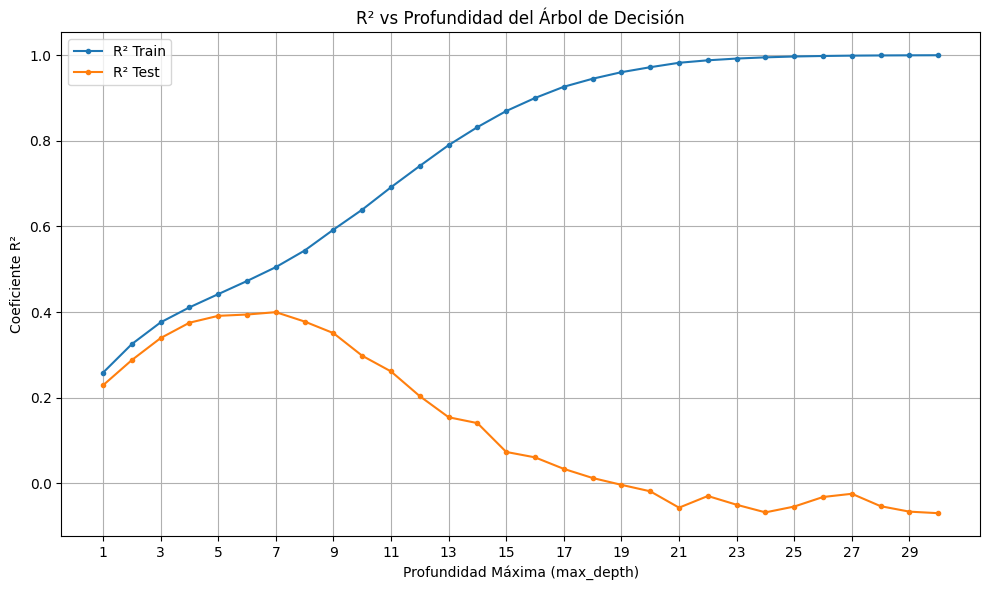

In [30]:
res = []
for md in range(1, 31):
    tree = DecisionTreeRegressor(max_depth=md, random_state=42)
    tree.fit(X_train, y_train)
    res.append(
        {
            "profundidad": md,
            "r2_train": tree.score(X_train, y_train),
            "r2_test": tree.score(X_test, y_test),
        },
    )

df_depth = pd.DataFrame(res)

plt.figure(figsize=(10, 6))
plt.plot(
    df_depth["profundidad"],
    df_depth["r2_train"],
    label="R² Train",
    marker="o",
    markersize=3,
)
plt.plot(
    df_depth["profundidad"],
    df_depth["r2_test"],
    label="R² Test",
    marker="o",
    markersize=3,
)
plt.title("R² vs Profundidad del Árbol de Decisión")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("Coeficiente R²")
plt.xticks(range(1, 31, 2))
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.show()

Al final la profundidad del arbol debe ser entre 5 y 7, ya que estos valores estan cerca del R^2 de Train pero no empiezan a empeorar su rendimiento R^2

## Resultados

### Influencia de las features en la prediccion del modelo

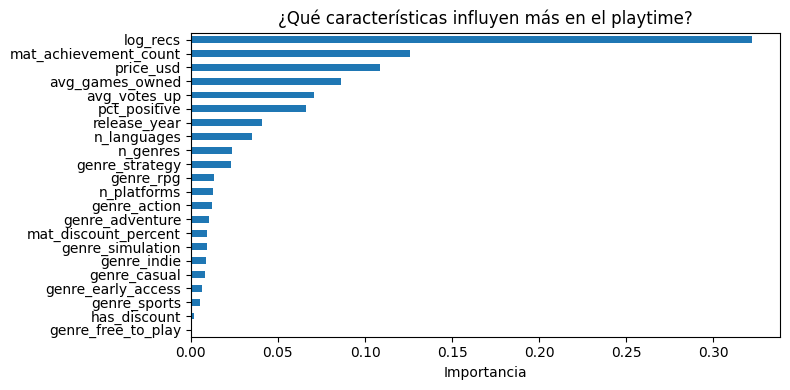

In [31]:
importancia = pd.Series(
    modelo_rf.feature_importances_,
    index=features,
).sort_values()

plt.figure(figsize=(8, 4))
importancia.plot.barh()
plt.xlabel("Importancia")
plt.title("¿Qué características influyen más en el playtime?")
plt.tight_layout()
plt.show()

Se puede apreciar que la cantidad de recomendaciones (31%), la cantidad de logros (12.7%) 
y el precio del juego (10.8%) son las características que más influyen en el tiempo 
invertido en el juego. Luego le siguen la cantidad de juegos que tiene el usuario (8.7%), 
la cantidad de votos positivos (7.2%) y el porcentaje de reviews positivas (6.9%). 

También es notable que la cantidad de idiomas, géneros y plataformas son factores a 
considerar, aunque con menor peso. El eje de "Importancia" indica qué proporción del 
poder predictivo del modelo aporta cada variable, se calcula midiendo cuánto reduce 
cada feature el error en los árboles del Random Forest, y los valores suman 1.0 (100%).

## Grafico de dispercion Random Forest

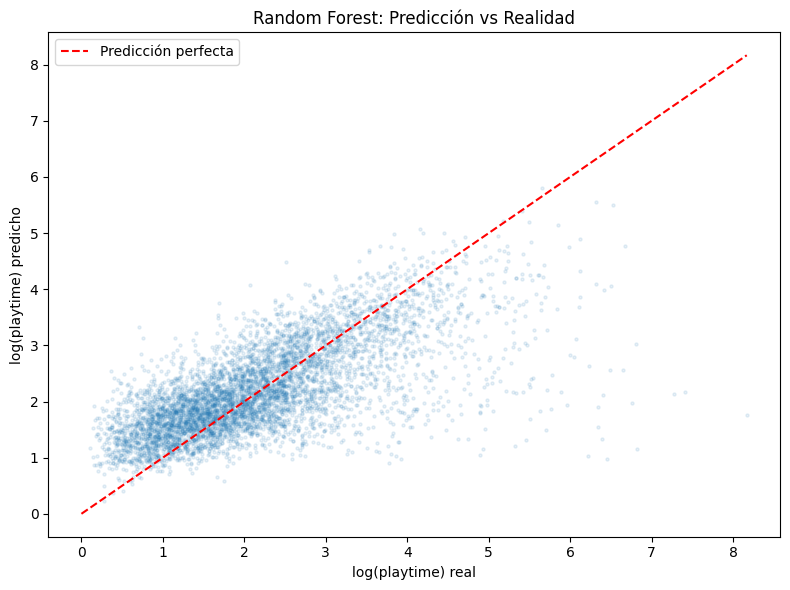

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.1, s=5)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot(
    [0, max_val],
    [0, max_val],
    color="red",
    linestyle="--",
    label="Predicción perfecta",
)
plt.xlabel("log(playtime) real")
plt.ylabel("log(playtime) predicho")
plt.title("Random Forest: Predicción vs Realidad")
plt.legend()
plt.tight_layout()
plt.show()

Comparando el tiempo de juego real con el tiempo de juego predicho, se puede observar una ligera tendencia a la prediccion perfecta en el grafico. Se puede apreciar que para valores altos el modelo no puede predecir correctamente. Sin embargo, para los valores bajos, puede predecirlo medianamente bien, con un desplazamiento a una prediccion mayor a la esperada.